In [42]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Blatt 8
## Nr.1


In [43]:
df=pd.read_csv("Input/rawdata_luftqualitaet.csv")
features=[
    'humidity_inside',
    'temperature_inside',
    'co2_inside',
    'temperature_heater',
    'temperature_wall_inside'
]

X = df[features]
y = df["state_air_quality"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



### a)

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


model = Sequential()

model.add(Dense(60, activation="relu", input_shape=(5,)))
model.add(Dense(60, activation="relu"))
model.add(Dense(3, activation="softmax"))

model.summary()


C:\Users\Louis Laptop\PycharmProjects\JupyterProject\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 60)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 60)             │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 3)              │           183 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,203 (16.42 KB)

 Trainable params: 4,203 (16.42 KB)

 Non-trainable params: 0 (0.00 B)

### b)

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6011 - loss: 0.9331 - val_accuracy: 0.8207 - val_loss: 0.6560
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8648 - loss: 0.5219 - val_accuracy: 0.8696 - val_loss: 0.4099
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8907 - loss: 0.3651 - val_accuracy: 0.9022 - val_loss: 0.3120
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9057 - loss: 0.2937 - val_accuracy: 0.9022 - val_loss: 0.2561
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9126 - loss: 0.2478 - val_accuracy: 0.9130 - val_loss: 0.2185
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9112 - loss: 0.2140 - val_accuracy: 0.9239 - val_loss: 0.1834
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9303 - loss: 0.1849 - val_accuracy: 0.9185 - val_loss: 0.1789
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9440 - loss: 0.1641 - val_accuracy: 0.9565 - 

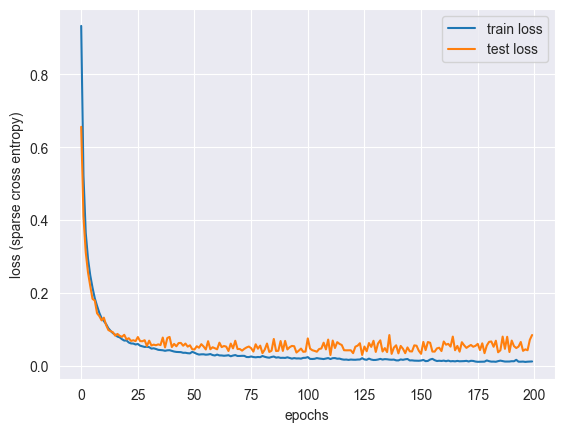

In [45]:
import matplotlib.pyplot as plt

# Modell kompilieren
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Trainieren: mind. 200 Epochen
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),  # "test loss" im Plot entspricht dann val_loss
    verbose=1
)

# Loss-Kurven plotten (Overfitting sichtbar machen)
plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="test loss")  # heißt in Keras val_loss
plt.xlabel("epochs")
plt.ylabel("loss (sparse cross entropy)")
plt.legend()
plt.show()


## Nr.2
### a)

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# Modell wie in 1a
model = Sequential()
model.add(Dense(60, activation="relu", input_shape=(5,)))
model.add(Dense(60, activation="relu"))
model.add(Dense(3, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# EarlyStopping Callback
early_stop = EarlyStopping(
    monitor="val_loss",         # worauf schauen wir?
    patience=10,                # wie viele Epochen ohne Verbesserung warten?
    restore_best_weights=True   # nach Training zurück zu den besten Gewichten
)
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 60)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 60)             │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 3)              │           183 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,203 (16.42 KB)

 Trainable params: 4,203 (16.42 KB)

 Non-trainable params: 0 (0.00 B)

### b)

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7760 - loss: 0.7651 - val_accuracy: 0.8152 - val_loss: 0.5224
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8210 - loss: 0.4563 - val_accuracy: 0.8587 - val_loss: 0.3813
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9030 - loss: 0.3468 - val_accuracy: 0.8859 - val_loss: 0.3059
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9112 - loss: 0.2846 - val_accuracy: 0.9076 - val_loss: 0.2567
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9112 - loss: 0.2386 - val_accuracy: 0.9022 - val_loss: 0.2226
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9276 - loss: 0.2044 - val_accuracy: 0.9239 - val_loss: 0.1929
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9385 - loss: 0.1775 - val_accuracy: 0.9402 - val_loss: 0.1681
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9426 - loss: 0.1558 - val_accuracy: 0.9293 - 

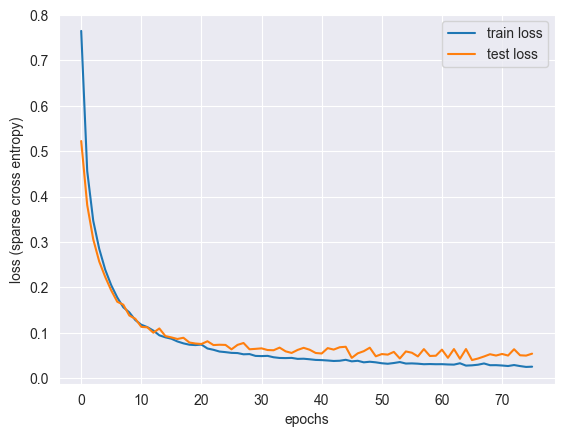

Training gestoppt nach Epochen: 76


In [47]:
import matplotlib.pyplot as plt

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# Plot wie vorher
plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="test loss")  # Keras nennt es val_loss
plt.xlabel("epochs")
plt.ylabel("loss (sparse cross entropy)")
plt.legend()
plt.show()

print("Training gestoppt nach Epochen:", len(history.history["loss"]))


## Nr.3
### a)

In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l2

lambda_l2 = 1e-3

model = Sequential()
model.add(Dense(60, activation="relu", input_shape=(5,),
                kernel_regularizer=l2(lambda_l2)))
model.add(Dense(60, activation="relu",
                kernel_regularizer=l2(lambda_l2)))
model.add(Dense(3, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 60)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 60)             │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 3)              │           183 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,203 (16.42 KB)

 Trainable params: 4,203 (16.42 KB)

 Non-trainable params: 0 (0.00 B)

### b)

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7418 - loss: 0.9035 - val_accuracy: 0.8152 - val_loss: 0.6639
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8142 - loss: 0.5878 - val_accuracy: 0.8207 - val_loss: 0.5054
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8634 - loss: 0.4606 - val_accuracy: 0.8804 - val_loss: 0.4066
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9085 - loss: 0.3833 - val_accuracy: 0.8859 - val_loss: 0.3388
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9016 - loss: 0.3243 - val_accuracy: 0.9076 - val_loss: 0.2923
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9194 - loss: 0.2813 - val_accuracy: 0.9185 - val_loss: 0.2588
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9344 - loss: 0.2528 - val_accuracy: 0.9402 - val_loss: 0.2313
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9536 - loss: 0.2299 - val_accuracy: 0.9402 - 

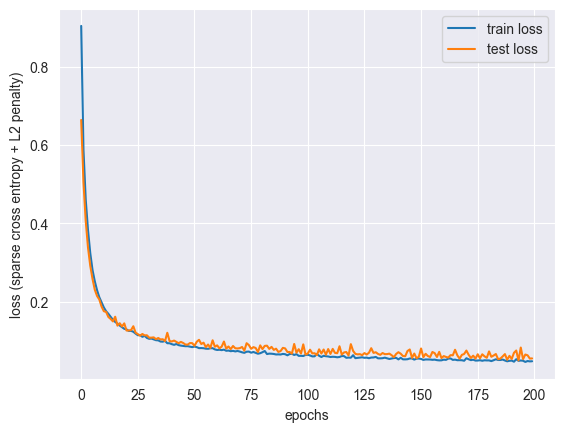

In [49]:
import matplotlib.pyplot as plt

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="test loss")
plt.xlabel("epochs")
plt.ylabel("loss (sparse cross entropy + L2 penalty)")
plt.legend()
plt.show()
